# Data Loading and Inspection

Run the code cells in this first section to load the Titanic dataset and inspect it. Take some time to explore the outputs of these cells to get a sense of what information the dataset contains. Look out for column names, data types, sample values, and some summary statistics which will be needed later in this assignment. Note: This version of the Titanic dataset has already been split into training and test sets for predictive modeling. You will only be working with the training set stored in train.csv in this assignment. A description of each column in the dataset can be found below:

- PassengerId - Unique identifier assigned to each passenger
- Survived - Whether the passenger survived, 0 = No, 1 = Yes
- Pclass - Passenger class, 1 = First Class, 2 = Second Class, 3 = Third Class
- Name - Passenger's full name, including title (Mr., Mrs., Miss., Master., etc.)
- Sex - Passenger's sex: male or female
- Age - Passenger age in years
- SibSp - Number of siblings and spouses aboard
- Parch - Number of parents and children aboard
- Ticket - Ticket number
- Fare - Ticket fare paid
- Cabin - Cabin number
- Embarked - Port of embarkation, S = Southampton, C = Cherbourg, Q = Queenstown

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress excessive warning messages
import warnings
warnings.filterwarnings("ignore")

# Read data
train = pd.read_csv("titanic/train.csv")

In [2]:
# Checkout out first few rows
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Checkout out dataframe info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Describe the dataframe including non-numeric columns
train.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## Target Distribution

The target in this dataset is slightly imbalanced, but the imbalance isn't extreme enough to cause concern later.

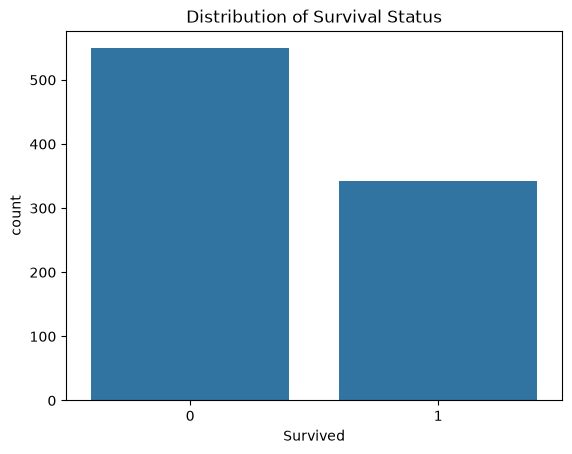

In [5]:
# Visualize the dataset, starting with the Survived distribution
sns.countplot(x = "Survived", data = train)
plt.title("Distribution of Survival Status")
plt.show()

In [6]:
# Check for target imbalance
train['Survived'].value_counts(normalize = True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

# Data Quality and Cleaning

In this section, you will inspect the data for quality issues and peform some minor cleaning. Using pandas dataframe attributes and methods, complete the actions requested in the markdown cells.

The first step will be to ensure that appropriate data types are set for all columns. Pandas automatically assigns data types when the data is loaded from a CSV, but the generic "object" data type is usually assigned to all columns containing text. The "category" data type is better when working with columns that contain categorical data because pandas can store and access the data more efficiently. 

1. Select all columns with the "object" data type and convert them to the "category" data type.

In [7]:
# Convert "object" columns to category data type to save memory and 
# improve performance
cat_cols = train.select_dtypes(include='object').columns.to_list()
train[cat_cols] = train[cat_cols].astype('category')

2. Use an appropriate attribute to display the data types for each column.

In [8]:
# Check data types after conversion
train.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name           category
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket         category
Fare            float64
Cabin          category
Embarked       category
dtype: object

3. Use appropriate methods to count the number of duplicate rows in the dataset. There shouldn't be any duplicate rows.

In [9]:
# Verify that there are no duplicate rows in the dataset
train.duplicated().sum()

np.int64(0)

4. Use appropriate methods to determine the total number or the proportion of missing values in each column. Keep an eye out for columns with a large number of missing values.

In [10]:
# Count the number of missing values or the proportion of 
# missing values in each column using an appropriate method
train.isnull().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

Columns with a high proportion of missing values (>40%) typically make for poor features. Unless you can reliably determine an appropriate replacement value, they should not be used as features.

5. Based on your results from the previous code cell, choose 1 feature to drop and add its name to the "drop_cols" list in the next code cell. You don't need to drop the column now, the idea here is to keep track of columns that have poor predictive power in a list to facilitate feature selection later.

In [11]:
# Select one feature to drop based on a high number of missing values
drop_cols = ["Cabin"]

# EDA

Exploratory data analysis (EDA) is an important process for understading a dataset. This usually involves looking at summary statistics and data visualizations for clues on where to focus your analysis. When performing EDA to support predictive modeling, there are some specific strategies that are particularly useful. In this section, EDA will be applied to identify strong features to use for a classification model as well as identifying weak features for removal. In classification problems, a strong feature is one which improves your ability to differentiate between target classes. Weak features are those that provide little or no information towards identifying the target class.

6. Use an appropriate method to count the number of unique values in each column. This is usually referred to as the "cardinality" of a column.

In [12]:
# Check the number of unique values in each column
train.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

Compare the counts of unique values in each column to the total number of rows in the dataframe. Columns with high cardinality (i.e., a large number of unique values) should be investigated to determine if they are worth using as features. If the high cardinality columns are discrete (i.e., "categorical" or "integer" types) such as "ID" columns, they usually contain little or no useful information relevant for predictive modeling and should be dropped. Continuous columns (i.e., "float" types) are likely to have high cardinality which is usually not a concern since these columns can take on essentially any decimal value. 

7. Based on your results from the previous code cell, choose 3 features to drop and add them to the "drop_cols" list in the next code cell using an appropriate method.

In [13]:
# Add columns to drop list that are no longer needed for modeling
drop_cols.extend(["PassengerId", "Name", "Ticket"])

## Numeric Features

Numeric features are most often columns with continuous numeric values (i.e., "float" types) although discrete numeric values (i.e., "integer" types) may behave as numeric features. These features are best explored using distribution plots such as histograms, box plots, and violin plots which show where the highest densities of values lie. When preparing numeric features for classification models, box plots or violin plots are a useful tools for comparing the distributions of numeric features across target categories. If the numeric feature distributions show differences across each target category, then this suggests that the feature may be useful to include in the predictive model. One example box plot is generated for you below.

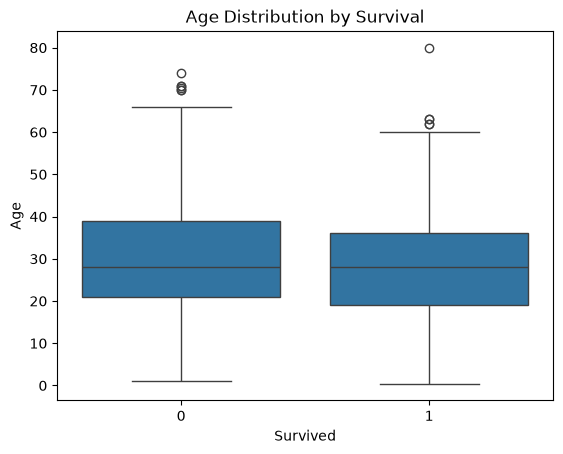

In [14]:
# Examine distribution of age with survival to look for separation
sns.boxplot(x = "Survived", y = "Age", data = train)
plt.title("Age Distribution by Survival")
plt.show()

8. Generate another boxplot to look at the distribution of your remaining "float" type column against survival status.

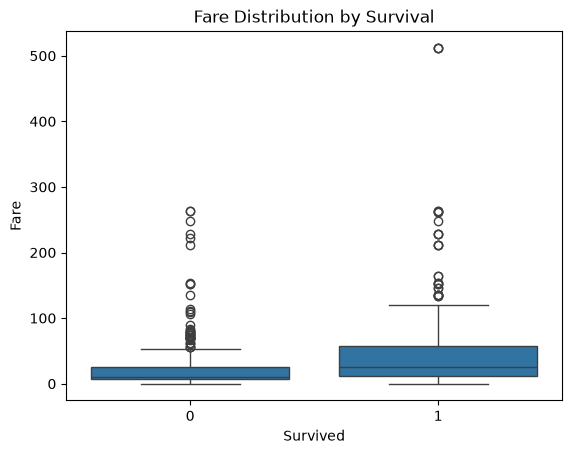

In [15]:
# Examine distribution of Fare with survival to look for separation
sns.boxplot(x = "Survived", y = "Fare", data = train)
plt.title("Fare Distribution by Survival")
plt.show()


9. You may decide whether you want to drop any of the the numeric features above based on your EDA. If you decide to drop one or more of them, add them to the "drop_cols" list in the next code cell, otherwise, leave the code cell blank.

## Categorical Features

Categorical features are columns with discrete values including "category" types and in many cases, discrete numeric values (i.e., "integer" types). In the case of "integer" types, numbers may be used as convenient labels where the values have no inherent interpretation as numbers (i.e., they are "nominal" values such as those in the "PassengerId" column) and can therefore be treated as categorical features. However, if an "integer" type column contains numbers in the usual sense, where the magnitude and order of values is meaningful (i.e., you can perform arithmetic using them such as the "SibSp" column), they are typically treated as numeric features, but may be treated as categorical features in the right context. In the latter case, if the cardinality of the column is low it may be useful to treat the numeric values as categories or groups to analyze differences between the categories.

Categorical features are best explored using discrete plots such as bar plots, count plots, and cross tabulations which show counts or proportions across categories. When preparing categorical features for classification models, cross tabulations (especially when combined with heatmaps) are a useful tool for comparing the proportions of categorical features across target categories. If the categorical feature proportions show differences across each target category, then this suggests that the feature may be useful to include in the predictive model.

### Cross Tabulation Heatmaps

Cross tabulations are a method for comparing two or more categories. In pandas, the crosstab function can be used to generate a cross tabulation matrix for two dataframe columns where the values in the matrix are the counts of records that belong to the categories indicated on the horizontal and vertical axes, by default. The normalize argument can be used to convert counts into proportions across rows, columns, or both. Setting normalize = "index" will ensure that the values in each row sum to 1. For example, in the next code cell, a cross tabulation heatmap is generated where the values are the proportions of each passenger class (Pclass) that died (0) and survived (1), respectively. So based on the values shown, 37% of passengers in Pclass 1 died while 63% of passengers in Pclass 1 survived. A cross tabulation matrix by itself is useful, but combining it with a heatmap visualization makes the differences across categories easier to spot, which in this case indicates that survival rates vary greatly across Pclass categories.


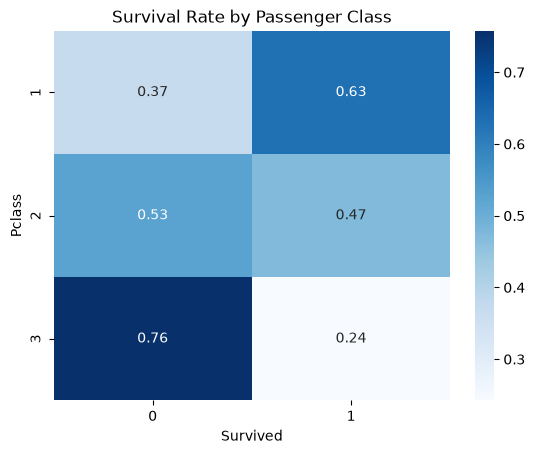

In [16]:
# Generate crosstabs of Pclass and Survived to examine survival rates by
# passenger class
prop = pd.crosstab(train["Pclass"], train["Survived"], normalize = "index")

# Use the crosstab matrix in a heatmap to make patterns easier to visualize
sns.heatmap(prop, annot = True, cmap = "Blues")
plt.title("Survival Rate by Passenger Class")
plt.show()

10. Generate a cross tabulation heatmap to visualize survival rates by "Sex" in the next code cell.

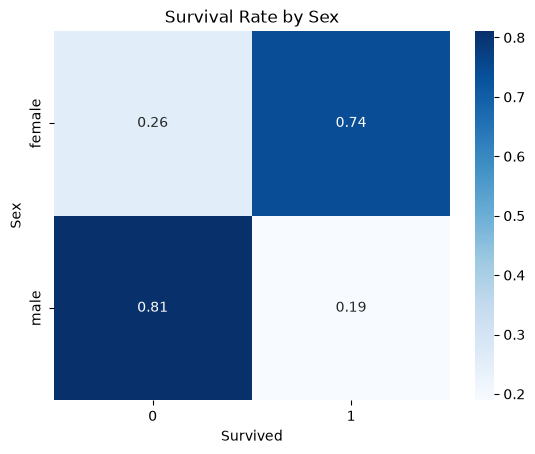

In [17]:
# Generate crosstabs of Sex and Survived to examine survival rates by sex
prop = pd.crosstab(train["Sex"], train["Survived"], normalize = "index")



# Use the crosstab matrix in a heatmap to make patterns easier to visualize
sns.heatmap(prop, annot = True, cmap = "Blues")
plt.title("Survival Rate by Sex")
plt.show()




11. Generate 1 crosstab heatmap to examine the survival rates for each remaining categorical feature (including integer columns), except any columns that you have chosen to drop, i.e., don't create a crosstab heatmap for columns in the "drop_cols" list that you have been populating. Use as many code cells as needed.

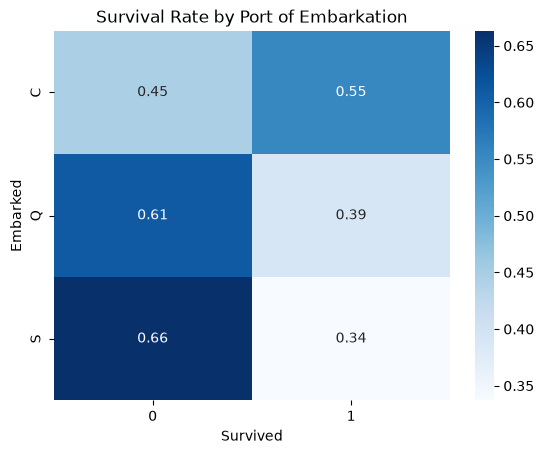

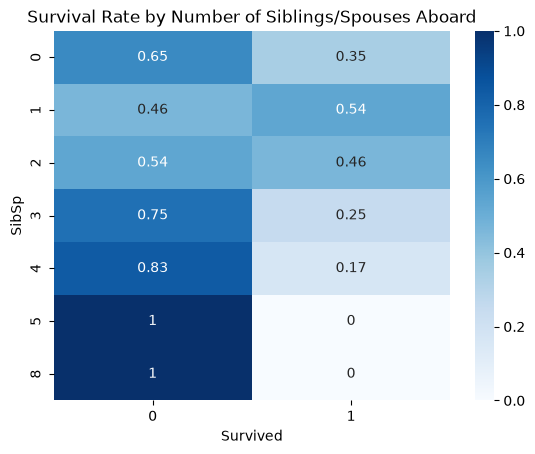

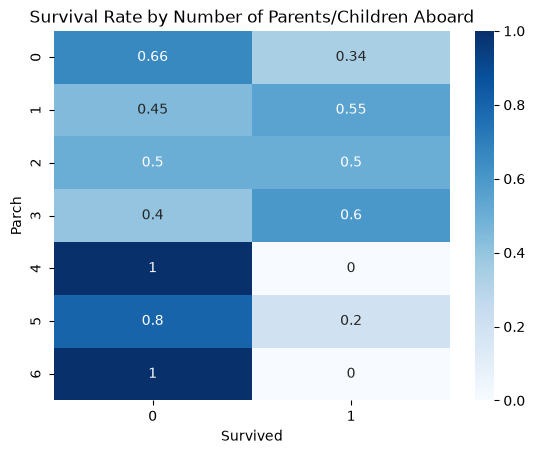

In [18]:
# Generate crosstabs of Embarked and Survived to examine survival rates by port of embarkation
prop = pd.crosstab(train["Embarked"], train["Survived"], normalize = "index")
sns.heatmap(prop, annot = True, cmap = "Blues")
plt.title("Survival Rate by Port of Embarkation")
plt.show()
# Generate crosstabs of SibSp and Survived to examine survival rates by number of siblings/spouses
prop = pd.crosstab(train["SibSp"], train["Survived"], normalize = "index")
sns.heatmap(prop, annot = True, cmap = "Blues")
plt.title("Survival Rate by Number of Siblings/Spouses Aboard")
plt.show()

# Generate crosstabs of Parch and Survived to examine survival rates by number of parents/children
prop = pd.crosstab(train["Parch"], train["Survived"], normalize = "index")
sns.heatmap(prop, annot = True, cmap = "Blues")
plt.title("Survival Rate by Number of Parents/Children Aboard")
plt.show()




12. You may decide whether you want to drop any of the the categorical features above based on your EDA. If you decide to drop one or more of them, add them to the "drop_cols" list in the next code cell, otherwise, leave the code cell blank.

# Feature Engineering

When training predictive models, it is common to encounter situations where the existing features could be improved in some way. The process of creating or modifying features to improve model performance is called "feature engineering". There is some variation in the interpretation of the term "feature engineering", but it usually includes common tasks like creating new features by combining existing features or transforming a feature in some way such as logarithmic scaling or binning continuous values into discrete groups. Deciding which features to engineer is not a trivial task and usually involves a combination of subject matter expertise and exploratory data analysis. Good feature engineering can improve a predictive model by reducing redundant features, increasing the interpretability of model predictions, and aligning features with business definitions. Note: It is not always necessary to engineer features if the existing features produce a model that performs satisfactorily given the task at hand.

In the following exercise, you will practice feature engineering by creating a "FamilySize" feature. The "SibSp" and "Parch" features in the dataset represent the number of "siblings and spouses" and "parents and children", respectively, that each passenger had onboard the Titanic with them. The "FamilySize" feature can be created by combining these two existing features together and accounting for the passenger themselves. 

13. In the following code cell, complete the code to create the new "FamilySize" feature in the train dataframe.

In [19]:
# Calculate family size from sibling/spouse and parent/children counts
# plus the passenger in question
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

14. Generate 1 crosstab heatmap to examine the survival rates for the new "FamilySize" feature you just created.

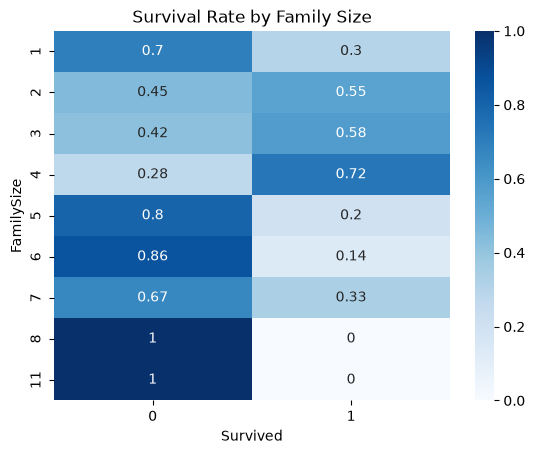

In [20]:
# Generate crosstabs of FamilySize and Survived to examine survival rates by 
# number of size of entire family aboard
prop = pd.crosstab(train["FamilySize"], train["Survived"], normalize = "index")

# Use the crosstab matrix in a heatmap to make patterns easier to visualize
sns.heatmap(prop, annot = True, cmap = "Blues")
plt.title("Survival Rate by Family Size")
plt.show()



One common objective of feature engineering is to create a new feature which captures similar information as several existing features. In this case, the new feature would replace the existing features from which it was derived, allowing for a simpler model to be trained. It is almost always preferable to train a model which requires fewer features so long as the performance doesn't suffer significantly. In the example above, one new feature was created by combining two existing features. As such, there is some redundancy between these three features which can be resolved by dropping two of them.

15. In the next code cell, add the two features that are no longer needed as a result of the feature engineering you performed to the "drop_cols" list for tracking purposes. These features won't be used for model training and will be dropped later.

In [21]:
# Add columns to drop list that are no longer needed for modeling
drop_cols.extend(["SibSp", "Parch"])

# Feature Selection

The last exercise for this assignment involves selecting the features to keep for training classification models in the next assignment. The selected features shouldn't include the target column or any features you chose to drop in the "drop_cols" list. Note: In practice, you would usually either drop the columns you don't want to keep or select the columns you do want to keep, as the result is essentially the same in both. Your "drop_cols" list is sorted and printed below for reference.

In [22]:
# View a sorted list of columns to drop
print(sorted(drop_cols))

['Cabin', 'Name', 'Parch', 'PassengerId', 'SibSp', 'Ticket']


16. Identify the name of the target column and store it in the "target" variable below.

In [23]:
# Define the target column
target = "Survived"

17. Identify all columns that you are planning to keep in the "select_cols" list below.

In [24]:
# Final features selected for modeling
select_cols = ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize"]

For the last step, the features and the target will be separated in prepartion for model training. A common convention is to store features in a variable called "X_train" and the target in a variable called "y_train".

18. Select the columns from the "train" dataframe that you want to use as features and store them in the "X_train" variable below. Select the target column from the "train" dataframe and store it in the "y_train" variable below. Print the first rows to inspect the final dataset.

In [25]:

# Define the features (X) and target (y) for modeling
X_train = train[select_cols]
y_train = train[target]

# Display the first few rows of the features and target
print("Features:")
print(X_train.head())
print("Target:")
print(y_train.head())

Features:
   Pclass     Sex   Age     Fare Embarked  FamilySize
0       3    male  22.0   7.2500        S           2
1       1  female  38.0  71.2833        C           2
2       3  female  26.0   7.9250        S           1
3       1  female  35.0  53.1000        S           2
4       3    male  35.0   8.0500        S           1
Target:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


19. In the following empty markdown cell, briefly summarize your reasons for choosing the features you selected in "select_cols". You may wish to discuss your reasons for dropping features that weren't included in "select_cols" to support your selections. If several features were selected/dropped for the same reason, you can discuss them as a group of features rather than individually to avoid repetition.

## Feature Selection Summary

I kept six features: Pclass, Sex, Age, Fare, Embarked, and FamilySize.

Sex was the clearest predictor in my EDA. Around 74% of women survived compared to only about 19% of men. Pclass also made a big difference, with 63% of first class passengers surviving versus 24% in third class. Fare followed the same pattern, since survivors generally paid more for their tickets, which makes sense given the link between fare and class. Age showed a smaller but still noticeable difference between the two groups, and since only about 20% of its values are missing, I think it's better to fill those in than lose the column. Embarked showed some variation by port, with passengers who boarded at Cherbourg (C) surviving at a higher rate. Finally, I created FamilySize by adding SibSp and Parch plus one for the passenger. Passengers in small families of 2 to 4 people had better survival rates than people travelling alone or in large groups.

I dropped the rest for a few reasons:

- Cabin is missing about 77% of its values, which is well past the 40% cutoff, and there's no reliable way to fill it in.
- PassengerId, Name, and Ticket have a unique or almost unique value for every passenger, so they don't help separate survivors from non-survivors.
- SibSp and Parch are already captured in FamilySize, so keeping them would just add redundancy.